<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/04_Vector_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Vector Applications

**Referensi:** Practical Linear Algebra for Data Science -- Mike X Cohen (O'Reilly, 2022)

---

## Ringkasan Chapter

Chapter ini menerapkan konsep vektor yang telah dipelajari ke masalah-masalah
nyata dalam data science dan machine learning.

**Topik yang dibahas:**
- Korelasi dan Cosine Similarity
- Time Series Filtering dan Feature Detection
- k-Means Clustering dari nol menggunakan vector operations

## 4.0 Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Library berhasil diimport.")
print(f"NumPy version: {np.__version__}")

Library berhasil diimport.
NumPy version: 2.0.2


## 4.1 Korelasi dan Cosine Similarity

### Korelasi Pearson

Dot product mengukur kesamaan antara dua vektor, tapi nilainya bergantung
pada skala data (misal: data dalam gram vs kilogram memberikan dot product
yang sangat berbeda).

**Korelasi Pearson** adalah dot product yang dinormalisasi:

    rho = (x_centered . y_centered) / (||x_centered|| * ||y_centered||)

Dua langkah normalisasi:
1. **Mean centering**: kurangi rata-rata dari setiap nilai
2. **Normalisasi norm**: bagi dengan hasil kali norm kedua vektor

Hasil: nilai antara -1 dan +1, terlepas dari skala data.

### Cosine Similarity

Cosine similarity adalah rumus dot product geometris yang diselesaikan
untuk komponen cosine:

    cos(theta) = (x . y) / (||x|| * ||y||)

**Perbedaan utama dari Pearson:**
- Pearson melakukan mean centering dulu, cosine similarity TIDAK
- Keduanya menggunakan normalisasi norm

Ini berarti untuk data yang sudah ter-mean-center, Pearson = Cosine similarity.

In [2]:
# Implementasi korelasi Pearson dari rumus dot product
def pearson_correlation(x, y):
    x_c = x - np.mean(x)   # mean centering
    y_c = y - np.mean(y)   # mean centering
    numerator   = np.dot(x_c, y_c)
    denominator = np.linalg.norm(x_c) * np.linalg.norm(y_c)
    return numerator / denominator

# Data contoh
np.random.seed(1)
n = 50
x = np.random.randn(n)
y_pos = x + np.random.randn(n) * 0.5     # korelasi positif
y_neg = -x + np.random.randn(n) * 0.5    # korelasi negatif
y_zero = np.random.randn(n)              # korelasi mendekati nol

print("=== Korelasi Pearson sebagai Dot Product Ternormalisasi ===")
for name, y in [("y_pos", y_pos), ("y_neg", y_neg), ("y_zero", y_zero)]:
    r_manual = pearson_correlation(x, y)
    r_numpy  = np.corrcoef(x, y)[0, 1]
    print(f"  corr(x, {name}) = {r_manual:.4f}  (np.corrcoef = {r_numpy:.4f})")

=== Korelasi Pearson sebagai Dot Product Ternormalisasi ===
  corr(x, y_pos) = 0.9262  (np.corrcoef = 0.9262)
  corr(x, y_neg) = -0.9097  (np.corrcoef = -0.9097)
  corr(x, y_zero) = 0.1182  (np.corrcoef = 0.1182)


In [3]:
# Implementasi cosine similarity
def cosine_similarity(x, y):
    dot_prod = np.dot(x, y)
    norm_product = np.linalg.norm(x) * np.linalg.norm(y)
    return dot_prod / norm_product

# Demonstrasi perbedaan Pearson vs Cosine Similarity
x1 = np.array([0, 1, 2, 3])
y1 = np.array([100, 101, 102, 103])  # y = x + 100

pearson_r   = pearson_correlation(x1, y1)
cosine_sim  = cosine_similarity(x1, y1)

print("=== Pearson vs Cosine Similarity ===")
print(f"x = {x1}")
print(f"y = {y1}  (y = x + 100)")
print()
print(f"Pearson r       = {pearson_r:.4f}")
print(f"Cosine similarity = {cosine_sim:.4f}")
print()
print("Pearson r = 1.0: hubungan linear sempurna (x dan y berubah searah)")
print("Cosine sim < 1.0: y jauh lebih besar secara absolut dari x (offset 100)")
print()
print("Kesimpulan: Pearson mengukur pola perubahan, cosine mengukur kesamaan arah.")

=== Pearson vs Cosine Similarity ===
x = [0 1 2 3]
y = [100 101 102 103]  (y = x + 100)

Pearson r       = 1.0000
Cosine similarity = 0.8083

Pearson r = 1.0: hubungan linear sempurna (x dan y berubah searah)
Cosine sim < 1.0: y jauh lebih besar secara absolut dari x (offset 100)

Kesimpulan: Pearson mengukur pola perubahan, cosine mengukur kesamaan arah.


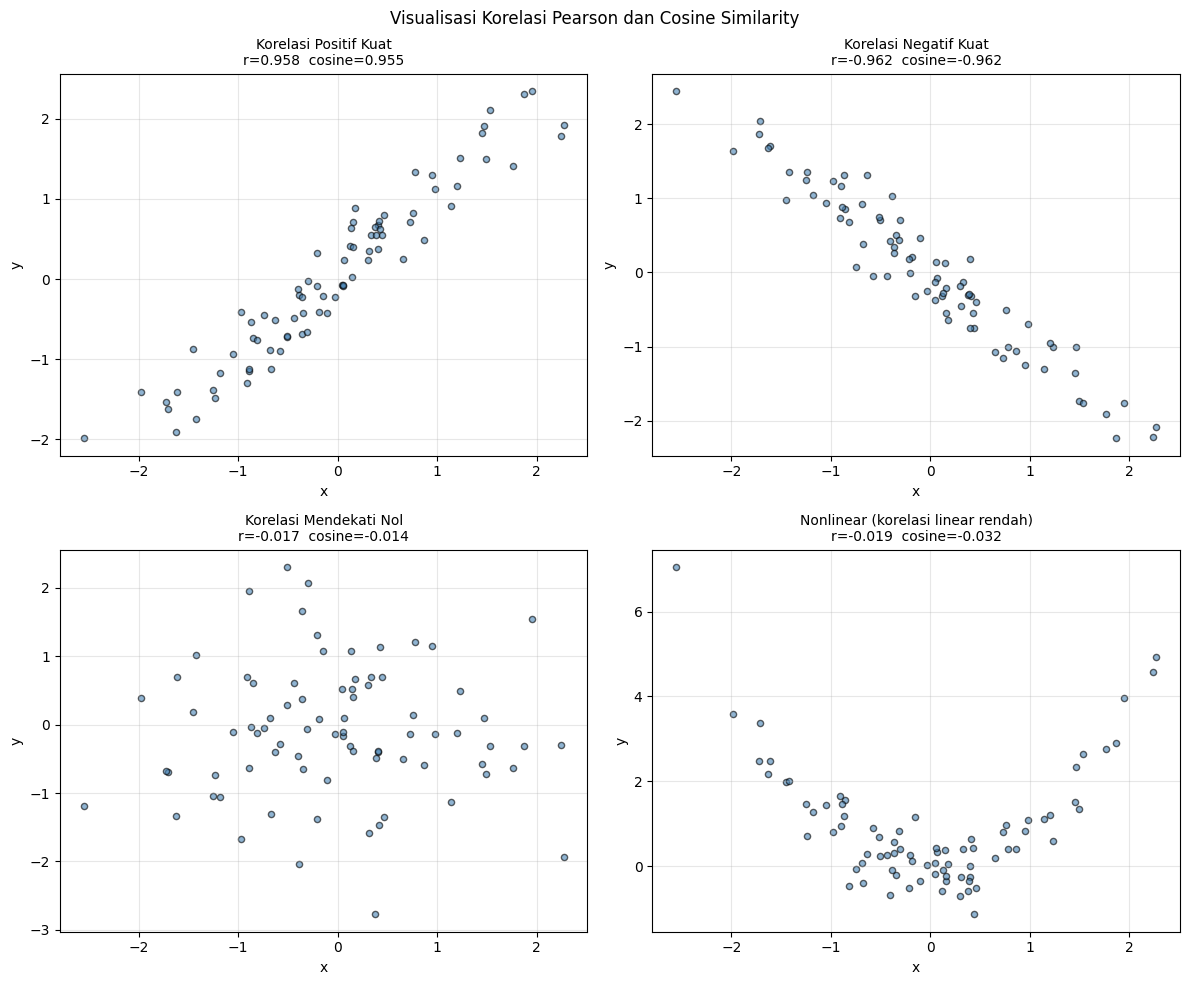

In [4]:
# Visualisasi korelasi positif, negatif, nol
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

np.random.seed(0)
n = 80
x_base = np.random.randn(n)

datasets = [
    (x_base, x_base + np.random.randn(n)*0.3,  "Korelasi Positif Kuat"),
    (x_base, -x_base + np.random.randn(n)*0.3, "Korelasi Negatif Kuat"),
    (x_base, np.random.randn(n),                "Korelasi Mendekati Nol"),
    (x_base, x_base**2 + np.random.randn(n)*0.5, "Nonlinear (korelasi linear rendah)"),
]

for ax, (x, y, title) in zip(axes, datasets):
    r = pearson_correlation(x, y)
    cs = cosine_similarity(x, y)
    ax.scatter(x, y, color="steelblue", edgecolors="k", s=20, alpha=0.6)
    ax.set_title(f"{title}\nr={r:.3f}  cosine={cs:.3f}", fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)

plt.suptitle("Visualisasi Korelasi Pearson dan Cosine Similarity", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Visualisasi korelasi sebagai fungsi sudut antar vektor
print("=== Korelasi dan Sudut Antar Vektor ===")
print()

np.random.seed(5)
n = 30
x_ref = np.random.randn(n)
x_ref = x_ref - np.mean(x_ref)  # mean center

angles_deg = [0, 30, 60, 90, 120, 150, 180]
print(f"{'Sudut (deg)':>15} {'Cos(theta)':>15} {'Pearson r (approx)':>20}")
print("-" * 53)

for angle in angles_deg:
    # Buat vektor y dengan sudut tertentu terhadap x_ref
    y = np.cos(np.radians(angle)) * x_ref + np.sin(np.radians(angle)) * np.random.randn(n) * 0.1
    y = y - np.mean(y)

    r = pearson_correlation(x_ref, y)
    cos_angle = np.cos(np.radians(angle))
    print(f"{angle:>15} {cos_angle:>15.4f} {r:>20.4f}")

print()
print("Tanda dot product = tanda korelasi = fungsi cos(sudut) antar vektor.")

=== Korelasi dan Sudut Antar Vektor ===

    Sudut (deg)      Cos(theta)   Pearson r (approx)
-----------------------------------------------------
              0          1.0000               1.0000
             30          0.8660               0.9978
             60          0.5000               0.9826
             90          0.0000              -0.1097
            120         -0.5000              -0.9870
            150         -0.8660              -0.9987
            180         -1.0000              -1.0000

Tanda dot product = tanda korelasi = fungsi cos(sudut) antar vektor.


## 4.2 Time Series Filtering dan Feature Detection

### Konsep Filtering

**Filtering** adalah metode deteksi fitur, di mana sebuah template
(disebut **kernel**) dicocokkan dengan bagian-bagian dari sinyal time series.

Hasil filtering adalah time series baru yang menunjukkan seberapa banyak
sinyal di setiap titik waktu cocok dengan karakteristik kernel.

### Mekanisme: Dot Product

Mekanisme filtering adalah menghitung **dot product** antara kernel dan
potongan pendek dari sinyal data sepanjang kernel. Prosedur ini:

1. Pilih potongan sinyal sepanjang kernel
2. Hitung dot product antara kernel dan potongan tersebut
3. Hasilkan satu titik waktu dalam sinyal terfilter
4. Geser kernel satu langkah ke kanan
5. Ulangi

Prosedur ini disebut **konvolusi** secara formal (dengan beberapa langkah tambahan).

**Aplikasi:**
- Smoothing (rata-rata bergerak): kernel berisi nilai konstan
- Edge detection: kernel yang mendeteksi perubahan tajam
- Band-pass filtering: kernel yang merespons frekuensi tertentu

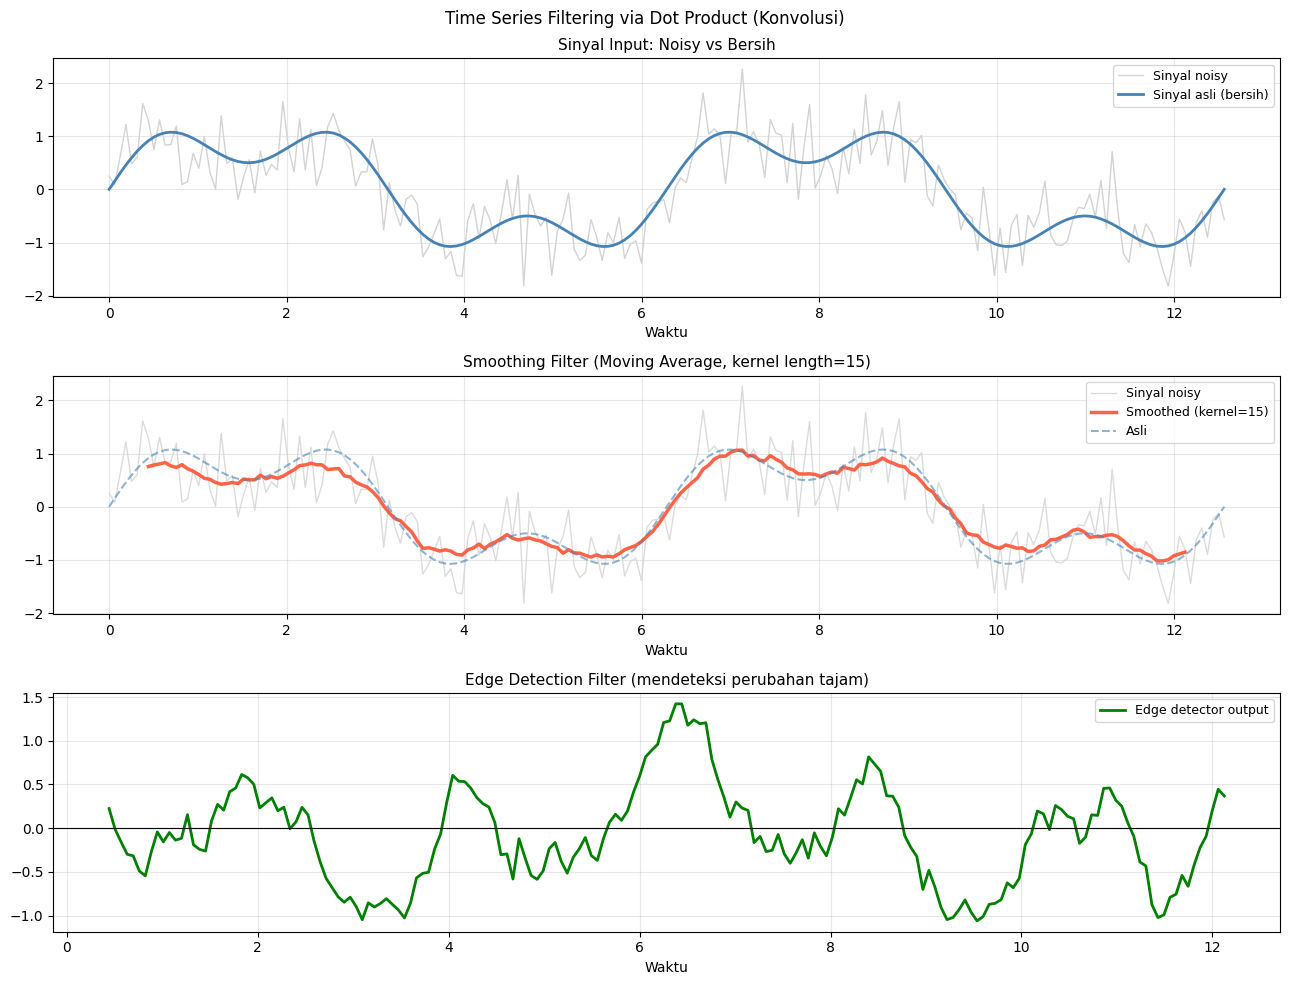

In [6]:
# Time series filtering: smoothing dan edge detection

# Buat sinyal time series dengan noise
np.random.seed(42)
n = 200
t = np.linspace(0, 4*np.pi, n)
signal_clean = np.sin(t) + 0.5 * np.sin(3*t)
signal_noisy = signal_clean + np.random.randn(n) * 0.5

# Kernel 1: Smoothing (kotak / rectangular)
k = 15  # panjang kernel
kernel_smooth = np.ones(k) / k  # rata-rata bergerak

# Kernel 2: Edge detection (deteksi perubahan tajam)
kernel_edge = np.concatenate([-np.ones(k//2), np.ones(k - k//2)]) / (k//2)

def convolve_dot(signal, kernel):
    k = len(kernel)
    n = len(signal)
    filtered = np.zeros(n - k + 1)
    for i in range(len(filtered)):
        segment = signal[i:i+k]
        filtered[i] = np.dot(segment, kernel)
    return filtered

smoothed = convolve_dot(signal_noisy, kernel_smooth)
edges    = convolve_dot(signal_noisy, kernel_edge)

# Indeks waktu yang valid setelah konvolusi
t_valid_s = t[k//2 : k//2 + len(smoothed)]
t_valid_e = t[k//2 : k//2 + len(edges)]

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(t, signal_noisy,  color="lightgray",  lw=1,   label="Sinyal noisy")
axes[0].plot(t, signal_clean,  color="steelblue",  lw=2,   label="Sinyal asli (bersih)")
axes[0].set_title("Sinyal Input: Noisy vs Bersih", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, signal_noisy,  color="lightgray",  lw=1,   label="Sinyal noisy", alpha=0.8)
axes[1].plot(t_valid_s, smoothed, color="tomato",  lw=2.5, label=f"Smoothed (kernel={k})")
axes[1].plot(t, signal_clean,  color="steelblue",  lw=1.5, label="Asli", alpha=0.6, linestyle="--")
axes[1].set_title(f"Smoothing Filter (Moving Average, kernel length={k})", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_valid_e, edges, color="green", lw=2, label="Edge detector output")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("Edge Detection Filter (mendeteksi perubahan tajam)", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel("Waktu")

plt.suptitle("Time Series Filtering via Dot Product (Konvolusi)", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Demonstrasi interaktif: kernel dan respons dot product
print("=== Demonstrasi: Kernel dan Dot Product ===")
print()

# Sinyal sederhana
sig = np.array([0, 0, 0, 1, 2, 3, 2, 1, 0, -1, -2, -3, -2, -1, 0, 0, 0], dtype=float)
kernel = np.array([1, 1, 1]) / 3.0  # rata-rata 3 titik

print("Sinyal:", sig)
print("Kernel:", kernel)
print()
print("Dot product pada setiap posisi:")
result = []
for i in range(len(sig) - len(kernel) + 1):
    seg = sig[i:i+len(kernel)]
    dp  = np.dot(seg, kernel)
    result.append(dp)
    print(f"  Posisi {i:2d}: seg={seg}  dp={dp:.4f}")

print()
print("Hasil filtering (smoothed):", np.round(result, 4))
print()
print("Dot product pada setiap posisi = nilai smoothed di posisi tersebut.")

=== Demonstrasi: Kernel dan Dot Product ===

Sinyal: [ 0.  0.  0.  1.  2.  3.  2.  1.  0. -1. -2. -3. -2. -1.  0.  0.  0.]
Kernel: [0.33333333 0.33333333 0.33333333]

Dot product pada setiap posisi:
  Posisi  0: seg=[0. 0. 0.]  dp=0.0000
  Posisi  1: seg=[0. 0. 1.]  dp=0.3333
  Posisi  2: seg=[0. 1. 2.]  dp=1.0000
  Posisi  3: seg=[1. 2. 3.]  dp=2.0000
  Posisi  4: seg=[2. 3. 2.]  dp=2.3333
  Posisi  5: seg=[3. 2. 1.]  dp=2.0000
  Posisi  6: seg=[2. 1. 0.]  dp=1.0000
  Posisi  7: seg=[ 1.  0. -1.]  dp=0.0000
  Posisi  8: seg=[ 0. -1. -2.]  dp=-1.0000
  Posisi  9: seg=[-1. -2. -3.]  dp=-2.0000
  Posisi 10: seg=[-2. -3. -2.]  dp=-2.3333
  Posisi 11: seg=[-3. -2. -1.]  dp=-2.0000
  Posisi 12: seg=[-2. -1.  0.]  dp=-1.0000
  Posisi 13: seg=[-1.  0.  0.]  dp=-0.3333
  Posisi 14: seg=[0. 0. 0.]  dp=0.0000

Hasil filtering (smoothed): [ 0.      0.3333  1.      2.      2.3333  2.      1.      0.     -1.
 -2.     -2.3333 -2.     -1.     -0.3333  0.    ]

Dot product pada setiap posisi = nilai s

## 4.3 k-Means Clustering

k-Means clustering adalah metode unsupervised untuk mengklasifikasikan data
multivariat ke dalam sejumlah kelompok berdasarkan minimisasi jarak ke centroid.

### Algoritma k-Means

1. **Inisialisasi**: pilih k centroid secara acak dari data
2. **Assign**: hitung jarak Euclidean setiap data point ke setiap centroid,
   lalu assign setiap data point ke centroid terdekat
3. **Update**: perbarui posisi centroid sebagai rata-rata semua data point di cluster itu
4. **Ulangi** langkah 2-4 sampai konvergen atau iterasi habis

### Peran Aljabar Linear

k-Means adalah contoh sempurna penggunaan vektor dalam machine learning:

- **Vektor**: setiap data point = vektor fitur
- **Norm**: jarak Euclidean = norm dari selisih dua vektor
- **Broadcasting**: menghitung jarak ke semua centroid sekaligus tanpa loop tambahan
- **Mean vektor**: centroid = rata-rata vektor-vektor dalam cluster

### Catatan tentang Squared Distance

Dalam implementasi, kita menggunakan **kuadrat jarak** (tanpa akar kuadrat).
Ini valid karena jarak dan kuadrat jarak bersifat monoton -- titik terdekat
dengan jarak maupun kuadrat jarak memberikan jawaban yang sama.
Menghilangkan operasi akar kuadrat menghemat komputasi.

In [8]:
# Implementasi k-Means dari nol menggunakan vector operations

def kmeans(data, k, n_iterations=10, seed=42):
    np.random.seed(seed)
    n_samples = data.shape[0]

    # Step 1: Inisialisasi -- pilih k data point acak sebagai centroid awal
    ridx = np.random.choice(n_samples, k, replace=False)
    centroids = data[ridx, :].copy()

    history = {"centroids": [centroids.copy()], "labels": []}

    for iteration in range(n_iterations):

        # Step 2: Hitung jarak (squared) dari setiap data point ke setiap centroid
        dists = np.zeros((n_samples, k))
        for ci in range(k):
            # Broadcasting: centroid[ci] di-broadcast ke semua baris data
            diff = data - centroids[ci, :]          # shape: (n_samples, n_features)
            dists[:, ci] = np.sum(diff**2, axis=1)  # squared Euclidean distance

        # Step 3: Assign setiap data point ke centroid terdekat
        labels = np.argmin(dists, axis=1)

        # Step 4: Update centroid = mean dari semua data point di cluster
        for ki in range(k):
            mask = labels == ki
            if mask.sum() > 0:
                centroids[ki, :] = data[mask, :].mean(axis=0)

        history["centroids"].append(centroids.copy())
        history["labels"].append(labels.copy())

    return labels, centroids, history


# Generate data: 3 cluster yang jelas terpisah
np.random.seed(0)
n_per_cluster = 50
centers = [(-3, -3), (0, 3), (3, -1)]
data = np.vstack([
    np.random.randn(n_per_cluster, 2) + np.array(c)
    for c in centers
])
np.random.shuffle(data)

k = 3
labels, final_centroids, history = kmeans(data, k=k, n_iterations=6)

print("=== k-Means Clustering ===")
print(f"Data: {data.shape[0]} sampel, {data.shape[1]} fitur")
print(f"k = {k} cluster")
print(f"Iterasi: {len(history['centroids'])-1}")
print()
for ki in range(k):
    n_in_cluster = np.sum(labels == ki)
    print(f"Cluster {ki}: {n_in_cluster} data point | centroid = {final_centroids[ki].round(3)}")

=== k-Means Clustering ===
Data: 150 sampel, 2 fitur
k = 3 cluster
Iterasi: 6

Cluster 0: 50 data point | centroid = [-2.983 -2.897]
Cluster 1: 51 data point | centroid = [1.000e-03 3.141e+00]
Cluster 2: 49 data point | centroid = [ 2.946 -1.068]


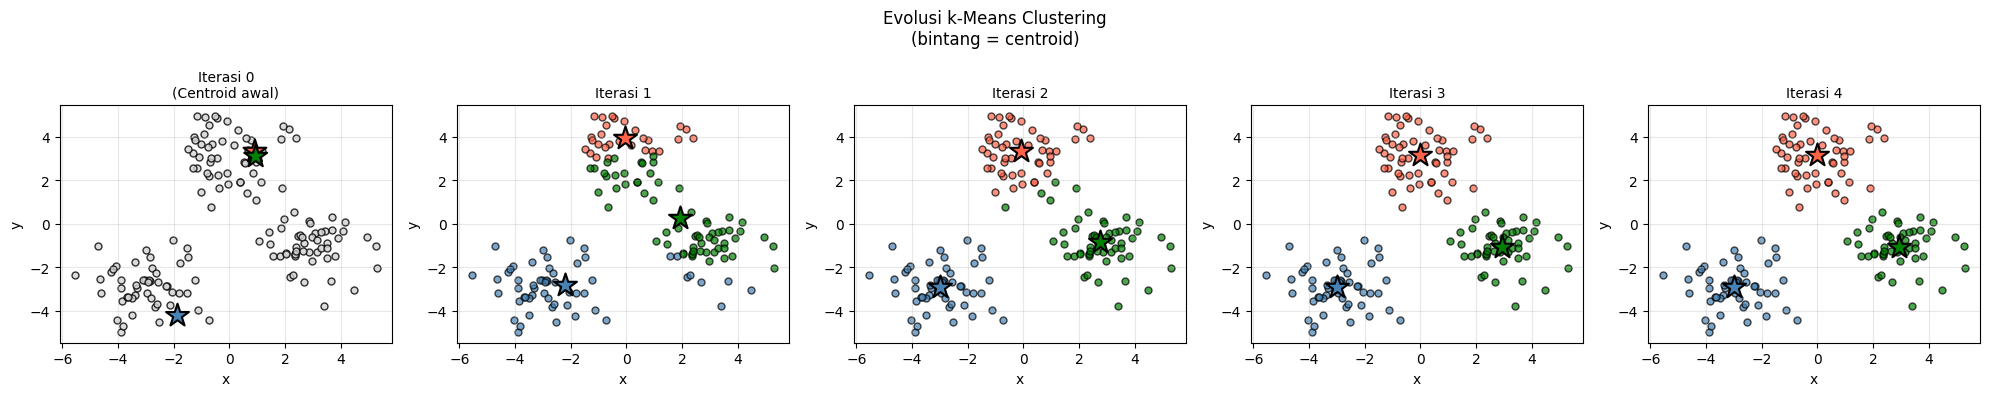

In [9]:
# Visualisasi evolusi k-Means
colors_km = ["steelblue", "tomato", "green"]
n_iter_show = min(4, len(history["labels"]))

fig, axes = plt.subplots(1, n_iter_show + 1, figsize=(4*(n_iter_show+1), 4))

# Panel 0: data awal tanpa label
ax = axes[0]
ax.scatter(data[:, 0], data[:, 1], color="lightgray", edgecolors="k",
           s=25, alpha=0.8)
init_centroids = history["centroids"][0]
ax.scatter(init_centroids[:, 0], init_centroids[:, 1],
           color=[colors_km[i] for i in range(k)], marker="*",
           s=300, zorder=5, edgecolors="black", lw=1.5)
ax.set_title("Iterasi 0\n(Centroid awal)", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")

# Panel iterasi berikutnya
for it in range(n_iter_show):
    ax = axes[it + 1]
    cur_labels    = history["labels"][it]
    cur_centroids = history["centroids"][it + 1]

    for ki in range(k):
        mask = cur_labels == ki
        ax.scatter(data[mask, 0], data[mask, 1],
                   color=colors_km[ki], edgecolors="k", s=25, alpha=0.7)
        ax.scatter(cur_centroids[ki, 0], cur_centroids[ki, 1],
                   color=colors_km[ki], marker="*", s=300, zorder=5,
                   edgecolors="black", lw=1.5)

    ax.set_title(f"Iterasi {it+1}", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Evolusi k-Means Clustering\n(bintang = centroid)", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# Analisis detail: jarak dan assignment
print("=== Detail Step-by-Step k-Means (Iterasi Pertama) ===")
print()

# Ambil 5 data point pertama
data_sample = data[:5]
init_c = history["centroids"][0]

print("5 data point pertama:")
for i, pt in enumerate(data_sample):
    print(f"  Data {i}: {pt.round(4)}")
print()
print("Centroid awal:")
for ci, c in enumerate(init_c):
    print(f"  Centroid {ci}: {c.round(4)}")
print()

print("Jarak kuadrat setiap data point ke setiap centroid:")
print(f"{'Data':>6} " + " ".join([f"{'dist_C'+str(ci):>12}" for ci in range(k)]) + " {'Assigned':>10}")
print("-" * (6 + 13*k + 12))

for i, pt in enumerate(data_sample):
    dists_row = []
    for ci in range(k):
        d2 = np.sum((pt - init_c[ci])**2)
        dists_row.append(d2)
    assigned = np.argmin(dists_row)
    row = f"{i:>6} " + " ".join([f"{d:>12.4f}" for d in dists_row]) + f" {'C'+str(assigned):>10}"
    print(row)

print()
print("Assignment = indeks centroid dengan jarak kuadrat terkecil (argmin).")

=== Detail Step-by-Step k-Means (Iterasi Pertama) ===

5 data point pertama:
  Data 0: [-3.3873 -3.3023]
  Data 1: [ 2.9757 -1.738 ]
  Data 2: [-1.4672 -1.5306]
  Data 3: [ 1.8438 -0.2188]
  Data 4: [0.3764 1.9006]

Centroid awal:
  Centroid 0: [-1.8606 -4.2348]
  Centroid 1: [0.9209 3.3187]
  Centroid 2: [0.9494 3.0876]

Jarak kuadrat setiap data point ke setiap centroid:
  Data      dist_C0      dist_C1      dist_C2 {'Assigned':>10}
---------------------------------------------------------
     0       3.2005      62.3985      59.6376         C0
     1      29.6235      29.7931      27.3919         C2
     2       7.4674      29.2193      27.1679         C0
     3      29.8512      13.3660      11.7319         C2
     4      42.6477       2.3075       1.7372         C2

Assignment = indeks centroid dengan jarak kuadrat terkecil (argmin).


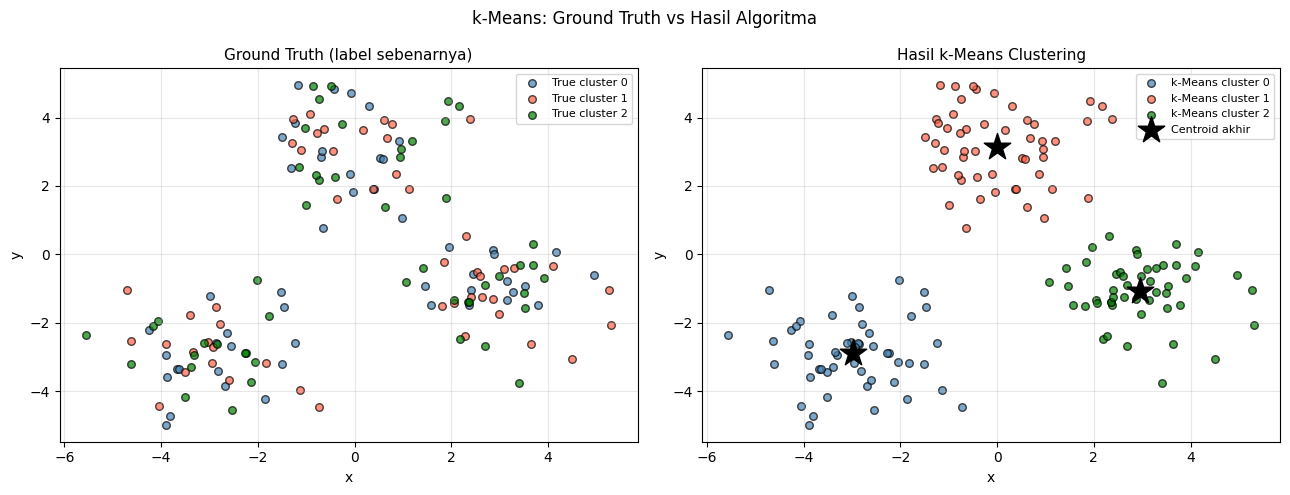

In [11]:
# Visualisasi final: hasil clustering dan perbandingan dengan ground truth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: ground truth (warna berdasarkan cluster asal)
true_labels = np.repeat([0, 1, 2], n_per_cluster)
np.random.seed(0)
shuffle_idx = np.random.permutation(len(data))
true_labels_shuffled = true_labels[np.argsort(shuffle_idx)]

# Reset untuk order yang benar
true_labels_ordered = np.zeros(len(data), dtype=int)
for i, ci in enumerate(centers):
    start = i * n_per_cluster
    end   = start + n_per_cluster

for ki in range(k):
    axes[0].scatter(data[true_labels_shuffled==ki, 0],
                    data[true_labels_shuffled==ki, 1],
                    color=colors_km[ki], edgecolors="k", s=30, alpha=0.7,
                    label=f"True cluster {ki}")

axes[0].set_title("Ground Truth (label sebenarnya)", fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Kanan: hasil k-Means
for ki in range(k):
    mask = labels == ki
    axes[1].scatter(data[mask, 0], data[mask, 1],
                    color=colors_km[ki], edgecolors="k", s=30, alpha=0.7,
                    label=f"k-Means cluster {ki}")

axes[1].scatter(final_centroids[:, 0], final_centroids[:, 1],
                color="black", marker="*", s=400, zorder=5,
                label="Centroid akhir")
axes[1].set_title("Hasil k-Means Clustering", fontsize=11)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.suptitle("k-Means: Ground Truth vs Hasil Algoritma", fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# Pengaruh inisialisasi: multiple runs untuk stabilitas
print("=== Pengaruh Inisialisasi pada k-Means ===")
print()

def kmeans_inertia(data, k, n_iter=20, seed=0):
    labels, centroids, _ = kmeans(data, k=k, n_iterations=n_iter, seed=seed)
    inertia = 0
    for ki in range(k):
        mask = labels == ki
        if mask.sum() > 0:
            diff = data[mask] - centroids[ki]
            inertia += np.sum(diff**2)
    return inertia, labels

inertias = []
for seed in range(10):
    inert, lbl = kmeans_inertia(data, k=k, seed=seed)
    inertias.append(inert)
    print(f"  Seed {seed:2d}: inertia = {inert:.4f}")

print()
print(f"Inertia terbaik : {min(inertias):.4f}")
print(f"Inertia terburuk: {max(inertias):.4f}")
print(f"Rasio best/worst: {max(inertias)/min(inertias):.4f}")
print()
print("Inisialisasi berbeda menghasilkan inertia berbeda.")
print("Praktik terbaik (sklearn): k-Means++ untuk inisialisasi yang lebih baik,")
print("dan menjalankan algoritma beberapa kali lalu ambil hasil terbaik (n_init).")

=== Pengaruh Inisialisasi pada k-Means ===

  Seed  0: inertia = 295.0213
  Seed  1: inertia = 295.0213
  Seed  2: inertia = 926.0212
  Seed  3: inertia = 295.0213
  Seed  4: inertia = 295.0213
  Seed  5: inertia = 295.0213
  Seed  6: inertia = 295.0213
  Seed  7: inertia = 295.0213
  Seed  8: inertia = 295.0213
  Seed  9: inertia = 295.0213

Inertia terbaik : 295.0213
Inertia terburuk: 926.0212
Rasio best/worst: 3.1388

Inisialisasi berbeda menghasilkan inertia berbeda.
Praktik terbaik (sklearn): k-Means++ untuk inisialisasi yang lebih baik,
dan menjalankan algoritma beberapa kali lalu ambil hasil terbaik (n_init).


=== Elbow Method: Memilih k Optimal ===
  k=1: inertia = 2134.9319
  k=2: inertia = 954.6492
  k=3: inertia = 295.0213
  k=4: inertia = 254.1588
  k=5: inertia = 224.3617
  k=6: inertia = 200.1681
  k=7: inertia = 167.8556


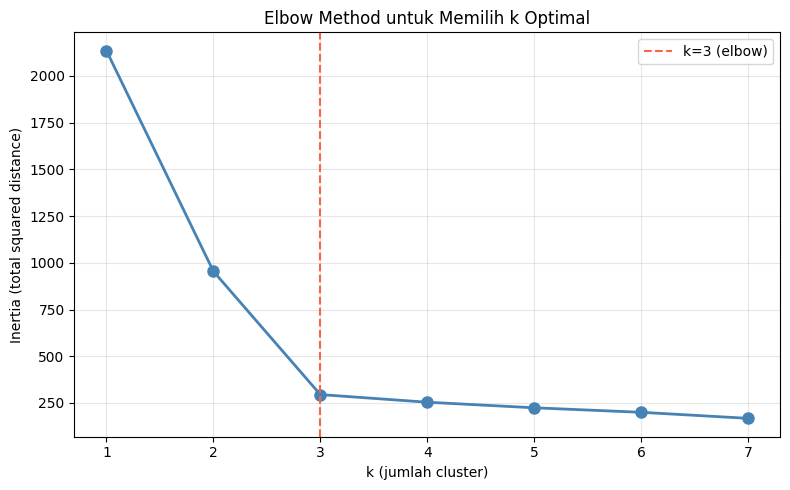


Elbow di k=3 menunjukkan bahwa k=3 adalah jumlah cluster optimal.
Di sebelah kiri elbow: penurunan inertia masih signifikan.
Di sebelah kanan elbow: penurunan inertia kecil (diminishing returns).


In [13]:
# Elbow method: memilih k optimal
print("=== Elbow Method: Memilih k Optimal ===")

inertias_k = []
k_range = range(1, 8)

for k_val in k_range:
    inert, _ = kmeans_inertia(data, k=k_val, n_iter=20, seed=42)
    inertias_k.append(inert)
    print(f"  k={k_val}: inertia = {inert:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias_k, "o-", color="steelblue", lw=2, markersize=8)
plt.axvline(3, color="tomato", linestyle="--", lw=1.5, label="k=3 (elbow)")
plt.xlabel("k (jumlah cluster)")
plt.ylabel("Inertia (total squared distance)")
plt.title("Elbow Method untuk Memilih k Optimal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Elbow di k=3 menunjukkan bahwa k=3 adalah jumlah cluster optimal.")
print("Di sebelah kiri elbow: penurunan inertia masih signifikan.")
print("Di sebelah kanan elbow: penurunan inertia kecil (diminishing returns).")

## 4.4 Latihan Kode

In [14]:
# Latihan 1: Implementasi korelasi dari rumus dot product
# Verifikasi bahwa implementasi manual = np.corrcoef

print("=== Latihan 1: Verifikasi Korelasi Manual vs np.corrcoef ===")
np.random.seed(99)

for trial in range(5):
    n = np.random.randint(10, 50)
    x = np.random.randn(n)
    y = np.random.randn(n) + 0.5 * x

    x_c = x - x.mean()
    y_c = y - y.mean()
    r_manual = np.dot(x_c, y_c) / (np.linalg.norm(x_c) * np.linalg.norm(y_c))
    r_numpy  = np.corrcoef(x, y)[0, 1]

    print(f"  Trial {trial+1} (n={n}): manual={r_manual:.6f}  np={r_numpy:.6f}  match={np.isclose(r_manual, r_numpy)}")

=== Latihan 1: Verifikasi Korelasi Manual vs np.corrcoef ===
  Trial 1 (n=11): manual=0.360626  np=0.360626  match=True
  Trial 2 (n=45): manual=0.597517  np=0.597517  match=True
  Trial 3 (n=41): manual=0.592436  np=0.592436  match=True
  Trial 4 (n=34): manual=0.461222  np=0.461222  match=True
  Trial 5 (n=14): manual=0.371281  np=0.371281  match=True


In [15]:
# Latihan 2: k-Means di data yang lebih kompleks
# Data dengan 5 cluster, dimensi lebih tinggi

print("=== Latihan 2: k-Means pada Data 5 Cluster, 3D ===")
np.random.seed(7)

centers_3d = [(-3, 0, 0), (3, 0, 0), (0, 3, 0), (0, -3, 0), (0, 0, 3)]
n_per = 30
data_3d = np.vstack([np.random.randn(n_per, 3) + np.array(c) for c in centers_3d])

k5 = 5
labels_3d, centroids_3d, _ = kmeans(data_3d, k=k5, n_iterations=20, seed=42)

print(f"Data: {data_3d.shape[0]} sampel, {data_3d.shape[1]} dimensi")
print(f"k = {k5}")
print()
print("Distribusi per cluster:")
for ki in range(k5):
    n_in = np.sum(labels_3d == ki)
    c    = centroids_3d[ki]
    print(f"  Cluster {ki}: {n_in:3d} data  |  centroid = [{c[0]:.2f}, {c[1]:.2f}, {c[2]:.2f}]")

=== Latihan 2: k-Means pada Data 5 Cluster, 3D ===
Data: 150 sampel, 3 dimensi
k = 5

Distribusi per cluster:
  Cluster 0:  27 data  |  centroid = [-0.18, 0.08, 2.97]
  Cluster 1:  34 data  |  centroid = [-2.89, -0.19, 0.30]
  Cluster 2:  28 data  |  centroid = [-0.06, -2.76, -0.65]
  Cluster 3:  29 data  |  centroid = [0.19, 2.98, -0.24]
  Cluster 4:  32 data  |  centroid = [2.88, -0.21, 0.21]


In [16]:
# Latihan 3: Cosine similarity untuk document similarity
# Vektor kata (bag of words sederhana)

print("=== Latihan 3: Cosine Similarity untuk Document Similarity ===")
print()

# Vocabulary: 6 kata
vocab = ["python", "data", "science", "machine", "learning", "matrix"]

# Dokumen sebagai vektor jumlah kata (bag of words)
doc1 = np.array([3, 2, 1, 0, 0, 1])  # "python data science matrix"
doc2 = np.array([1, 2, 0, 3, 2, 0])  # "machine learning data"
doc3 = np.array([2, 2, 1, 1, 1, 0])  # "python data science machine learning"
doc4 = np.array([0, 0, 0, 0, 0, 5])  # "matrix matrix matrix..."

docs = {"doc1 (Python DS)": doc1, "doc2 (ML focus)": doc2,
        "doc3 (Python+ML)": doc3, "doc4 (Matrix)": doc4}

print("Vocabulary:", vocab)
print()
print("Cosine Similarity antar dokumen:")
doc_names = list(docs.keys())
doc_vecs  = list(docs.values())

header = f"{'':>20}" + "".join([f"{n:>18}" for n in doc_names])
print(header)
for i, (n1, v1) in enumerate(docs.items()):
    row = f"{n1:>20}"
    for j, (n2, v2) in enumerate(docs.items()):
        cs = cosine_similarity(v1, v2)
        row += f"{cs:>18.4f}"
    print(row)

print()
print("Nilai mendekati 1 = sangat mirip, mendekati 0 = sangat berbeda.")
print("doc1 dan doc3 seharusnya paling mirip (keduanya punya Python dan data science).")

=== Latihan 3: Cosine Similarity untuk Document Similarity ===

Vocabulary: ['python', 'data', 'science', 'machine', 'learning', 'matrix']

Cosine Similarity antar dokumen:
                      doc1 (Python DS)   doc2 (ML focus)  doc3 (Python+ML)     doc4 (Matrix)
    doc1 (Python DS)            1.0000            0.4260            0.8563            0.2582
     doc2 (ML focus)            0.4260            1.0000            0.7817            0.0000
    doc3 (Python+ML)            0.8563            0.7817            1.0000            0.0000
       doc4 (Matrix)            0.2582            0.0000            0.0000            1.0000

Nilai mendekati 1 = sangat mirip, mendekati 0 = sangat berbeda.
doc1 dan doc3 seharusnya paling mirip (keduanya punya Python dan data science).


## 4.5 Ringkasan Chapter 4

### Aplikasi Vektor yang Telah Dipelajari

| Aplikasi | Operasi Vektor Utama | Kegunaan |
|----------|---------------------|----------|
| Korelasi Pearson | Dot product + normalisasi norm | Mengukur hubungan linear antar variabel |
| Cosine Similarity | Dot product + normalisasi norm (tanpa centering) | NLP, rekomendasi, clustering |
| Time Series Filtering | Dot product berulang (konvolusi) | Smoothing, edge detection, audio processing |
| k-Means Clustering | Norm (jarak), broadcasting, mean vektor | Segmentasi data tanpa label |

### Pelajaran Utama

1. **Dot product adalah fondasi** dari banyak analisis data science.
   Korelasi, cosine similarity, filtering -- semuanya dibangun di atas dot product.

2. **Broadcasting** memungkinkan komputasi efisien tanpa loop eksplisit
   (contoh: menghitung jarak ke semua centroid sekaligus).

3. **Normalisasi** penting untuk membuat metrik yang konsisten terlepas dari skala data.

4. **k-Means** adalah contoh sempurna bagaimana algoritma ML dibangun dari
   operasi vektor dasar: norm, broadcasting, dan mean.

### Koneksi ke Chapter Berikutnya

Semua konsep ini akan diperluas ke **matriks** di chapter 5 dan seterusnya:
- Korelasi -> matriks kovariansi
- Proyeksi vektor -> transformasi matriks
- k-Means -> SVD dan PCA untuk clustering dan dimensionality reduction